# Finalists Model Evaluation

This notebook evaluates the three models (Logistic Regression, Random Forest, Ensemble) on historical finalist labels using the prediction file `outputs/finalists_top_all.csv` and generates metrics, confusion matrices, ROC curves, threshold analysis, and visual summaries.

Outputs (saved to `outputs/finalists/`):
- `eval_metrics_table.csv` — table of metrics per model
- `eval_roc_curves.png` — ROC curves comparison
- `eval_confusion_matrices.png` — confusion matrices side-by-side
- `eval_metrics_bar.png` — grouped bar chart of metrics
- `eval_threshold_analysis.png` — precision/recall/F1 vs threshold for ensemble
- `eval_prob_dist.png` — probability distribution histograms
- `eval_feature_importances.png` (if model artifacts available)

Run cells in order. If model pickles are available in `outputs/finalists/` the notebook will attempt to load them to show feature importances; if not available it will skip that step.

In [ ]:
# Standard imports and config
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, balanced_accuracy_score, cohen_kappa_score, precision_recall_curve)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
try:
    import paths_util
except Exception:
    paths_util = None
OUT_DIR = paths_util.find_outputs_dir() if paths_util else Path('outputs') / 'finalists'
OUT_DIR = Path(OUT_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
# Load prediction file (generated earlier)
# find prediction file (finalists_top_all.csv) using paths_util
pred_candidate = paths_util.find_file('finalists_top_all.csv') if paths_util else None
pred_path = str(pred_candidate) if pred_candidate else os.path.join('outputs','finalists_top_all.csv')
if not os.path.exists(pred_path):
    raise FileNotFoundError(f'Predictions file not found at {pred_path} - make sure notebook that generates predictions has been run.')
preds = pd.read_csv(pred_path)
# standardize column names (accept prob_lr, prob_rf, ensemble_prob or prob_xgb)
for col in ['prob_lr','prob_rf','ensemble_prob']:
    if col not in preds.columns:
        raise ValueError(f'Missing column {col} in predictions file')
preds['team'] = preds['team'].astype(str)
preds.head()

,team,prob_lr,prob_rf,ensemble_prob
0,Brazil,0.905840,0.979238,0.948508
1,Germany,0.879878,0.947238,0.931672
2,France,0.804543,0.986571,0.919671
3,Argentina,0.811174,0.956905,0.911993
4,Netherlands,0.773322,0.988571,0.909931


In [5]:
# Ground truth mapping for historical finalists (2002-2022)
historical_finalists = {'Argentina','Brazil','Croatia','France','Germany','Italy','Netherlands','Spain','West Germany'}
preds['actual_finalist'] = preds['team'].isin(historical_finalists).astype(int)
print('Total teams:', len(preds))
print('Actual finalists (should be 9):', preds['actual_finalist'].sum())
preds[['team','ensemble_prob','actual_finalist']].head(12)

Total teams: 75
Actual finalists (should be 9): 9


,team,ensemble_prob,actual_finalist
0,Brazil,0.948508,1
1,Germany,0.931672,1
2,France,0.919671,1
3,Argentina,0.911993,1
4,Netherlands,0.909931,1
5,England,0.870980,0
6,Spain,0.865141,1
7,Italy,0.857474,1
8,Belgium,0.812913,0
9,Portugal,0.792406,0


In [ ]:
# Helper: calculate metrics given y_true, y_pred, y_prob
def calculate_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    metrics = {}
    metrics['TP'] = int(tp)
    metrics['FP'] = int(fp)
    metrics['FN'] = int(fn)
    metrics['TN'] = int(tn)
    metrics['Accuracy'] = accuracy_score(y_true, y_pred)
    metrics['Precision'] = precision_score(y_true, y_pred, zero_division=0)
    metrics['Recall'] = recall_score(y_true, y_pred, zero_division=0)
    metrics['F1-Score'] = f1_score(y_true, y_pred, zero_division=0)
    metrics['ROC-AUC'] = roc_auc_score(y_true, y_prob)
    metrics['Balanced Accuracy'] = balanced_accuracy_score(y_true, y_pred)
    metrics["Cohen's Kappa"] = cohen_kappa_score(y_true, y_pred)
    # Specificity = TN / (TN + FP) when there is at least 1 negative
    metrics['Specificity'] = (tn / (tn + fp)) if (tn + fp) > 0 else np.nan
    return metrics

# Evaluate three models using threshold 0.5
threshold = 0.5
y_true = preds['actual_finalist']
# Logistic
y_prob_lr = preds['prob_lr']
y_pred_lr = (y_prob_lr >= threshold).astype(int)
metrics_lr = calculate_metrics(y_true, y_pred_lr, y_prob_lr)
# Random Forest
y_prob_rf = preds['prob_rf']
y_pred_rf = (y_prob_rf >= threshold).astype(int)
metrics_rf = calculate_metrics(y_true, y_pred_rf, y_prob_rf)
# Ensemble
y_prob_ens = preds['ensemble_prob']
y_pred_ens = (y_prob_ens >= threshold).astype(int)
metrics_ens = calculate_metrics(y_true, y_pred_ens, y_prob_ens)

metrics_df = pd.DataFrame({
    'Logistic Regression': metrics_lr,
    'Random Forest': metrics_rf,
    'Ensemble': metrics_ens
})
metrics_df = metrics_df.T
metrics_df.to_csv(str(OUT_DIR / 'eval_metrics_table.csv'))
metrics_df.round(4)

,TP,FP,FN,TN,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Balanced Accuracy,Cohen's Kappa,Specificity
Logistic Regression,9.0,3.0,0.0,63.0,0.9600,0.7500,1.0,0.8571,0.9933,0.9773,0.8344,0.9545
Random Forest,9.0,5.0,0.0,61.0,0.9333,0.6429,1.0,0.7826,0.9781,0.9621,0.7454,0.9242
Ensemble,9.0,6.0,0.0,60.0,0.9200,0.6000,1.0,0.7500,0.9865,0.9545,0.7059,0.9091


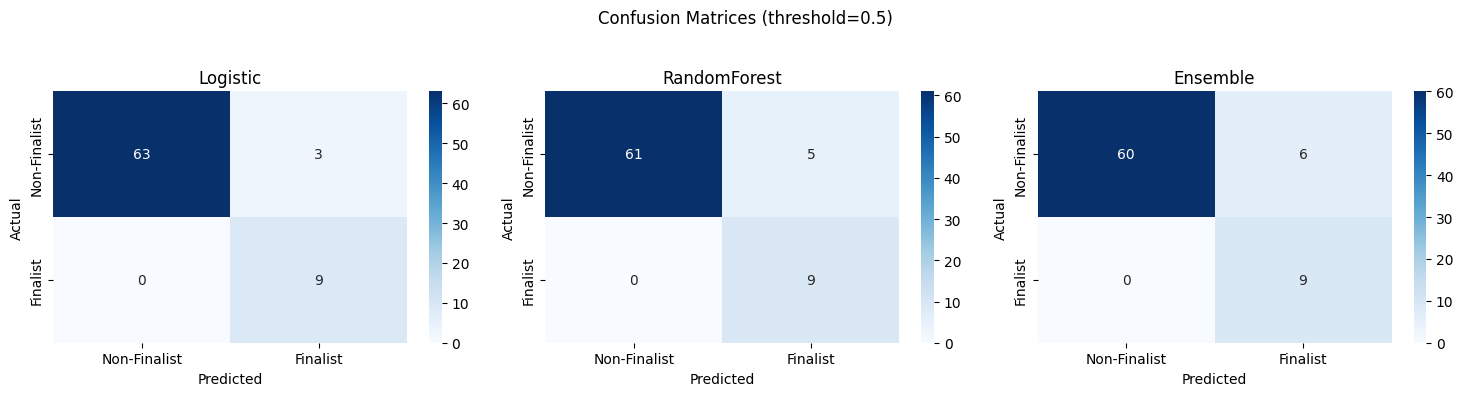

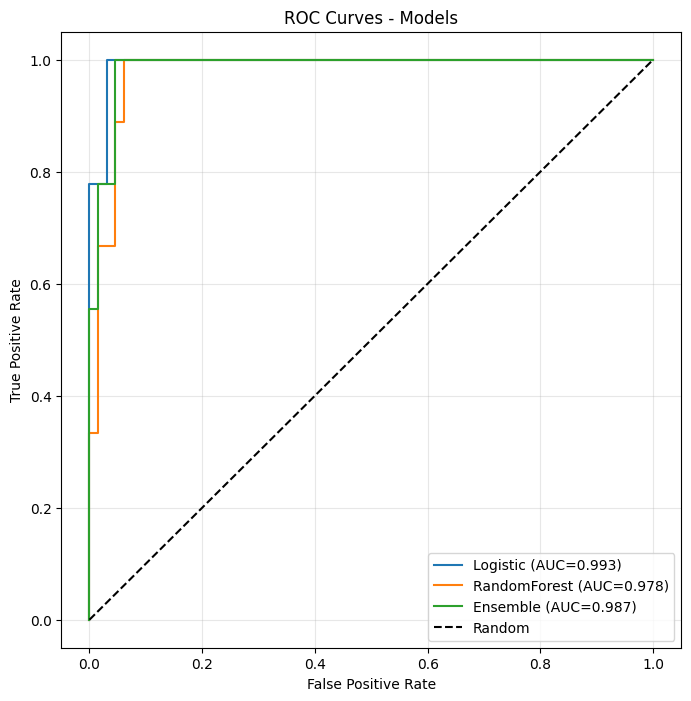

In [ ]:
# Confusion matrices and ROC curves
# Confusion matrices side-by-side
cms = {'Logistic': confusion_matrix(y_true, y_pred_lr), 'RandomForest': confusion_matrix(y_true, y_pred_rf), 'Ensemble': confusion_matrix(y_true, y_pred_ens)}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, cm) in zip(axes, cms.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Finalist','Finalist'], yticklabels=['Non-Finalist','Finalist'])
    ax.set_title(name)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices (threshold=0.5)')
plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig(str(OUT_DIR / 'eval_confusion_matrices.png'), dpi=300)
plt.show()

# ROC curves
fpr_lr, tpr_lr, thr_lr = roc_curve(y_true, y_prob_lr)
fpr_rf, tpr_rf, thr_rf = roc_curve(y_true, y_prob_rf)
fpr_ens, tpr_ens, thr_ens = roc_curve(y_true, y_prob_ens)
auc_lr = roc_auc_score(y_true, y_prob_lr)
auc_rf = roc_auc_score(y_true, y_prob_rf)
auc_ens = roc_auc_score(y_true, y_prob_ens)
plt.figure(figsize=(8, 8))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic (AUC={auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'RandomForest (AUC={auc_rf:.3f})')
plt.plot(fpr_ens, tpr_ens, label=f'Ensemble (AUC={auc_ens:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Models')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(str(OUT_DIR / 'eval_roc_curves.png'), dpi=300)
plt.show()

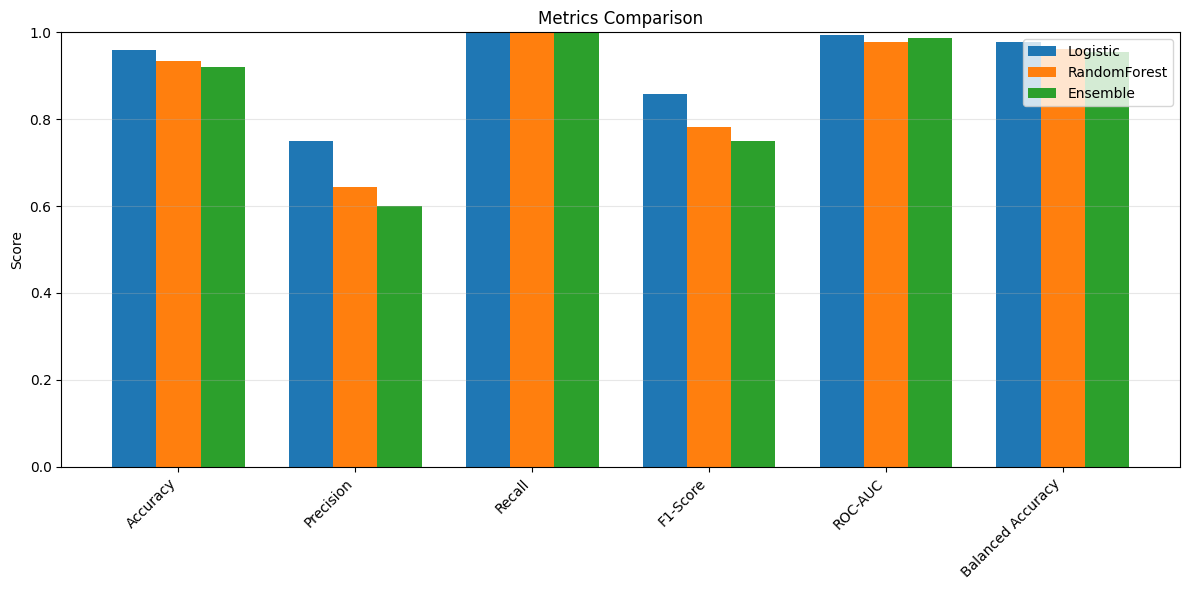

In [ ]:
# Metrics comparison bar chart
metrics_to_plot = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC','Balanced Accuracy']
x = np.arange(len(metrics_to_plot))
width = 0.25
vals_lr = [metrics_lr[m] for m in metrics_to_plot]
vals_rf = [metrics_rf[m] for m in metrics_to_plot]
vals_ens = [metrics_ens[m] for m in metrics_to_plot]
plt.figure(figsize=(12,6))
plt.bar(x - width, vals_lr, width, label='Logistic')
plt.bar(x, vals_rf, width, label='RandomForest')
plt.bar(x + width, vals_ens, width, label='Ensemble')
plt.xticks(x, metrics_to_plot, rotation=45, ha='right')
plt.ylim(0,1)
plt.ylabel('Score')
plt.title('Metrics Comparison')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(str(OUT_DIR / 'eval_metrics_bar.png'), dpi=300)
plt.show()

Best threshold for ensemble (max F1): 0.6410658291385273


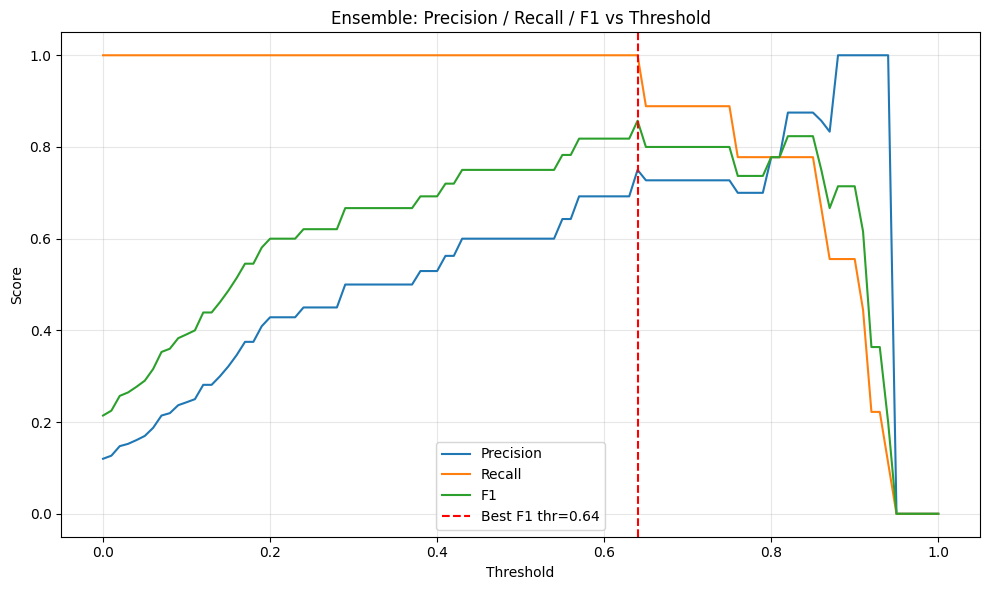

In [ ]:
# Threshold optimization for Ensemble using Precision-Recall and F1
prec, rec, thr = precision_recall_curve(y_true, y_prob_ens)
# note: precision_recall_curve returns array with len(thr)+1 for prec/rec
f1s = 2 * (prec * rec) / (prec + rec + 1e-12)
# Align thresholds to f1s (drop last element)
f1s_for_thr = f1s[:-1]
best_idx = np.argmax(f1s_for_thr) if len(f1s_for_thr)>0 else None
best_threshold = thr[best_idx] if best_idx is not None else 0.5
print('Best threshold for ensemble (max F1):', best_threshold)
# Plot metrics vs threshold (0.0-1.0 sample)
sample_thr = np.linspace(0.0,1.0,101)
prec_vals = []
rec_vals = []
f1_vals = []
for t in sample_thr:
    p = precision_score(y_true, (y_prob_ens>=t).astype(int), zero_division=0)
    r = recall_score(y_true, (y_prob_ens>=t).astype(int), zero_division=0)
    f = f1_score(y_true, (y_prob_ens>=t).astype(int), zero_division=0)
    prec_vals.append(p); rec_vals.append(r); f1_vals.append(f)
plt.figure(figsize=(10,6))
plt.plot(sample_thr, prec_vals, label='Precision')
plt.plot(sample_thr, rec_vals, label='Recall')
plt.plot(sample_thr, f1_vals, label='F1')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best F1 thr={best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Ensemble: Precision / Recall / F1 vs Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(OUT_DIR / 'eval_threshold_analysis.png'), dpi=300)
plt.show()

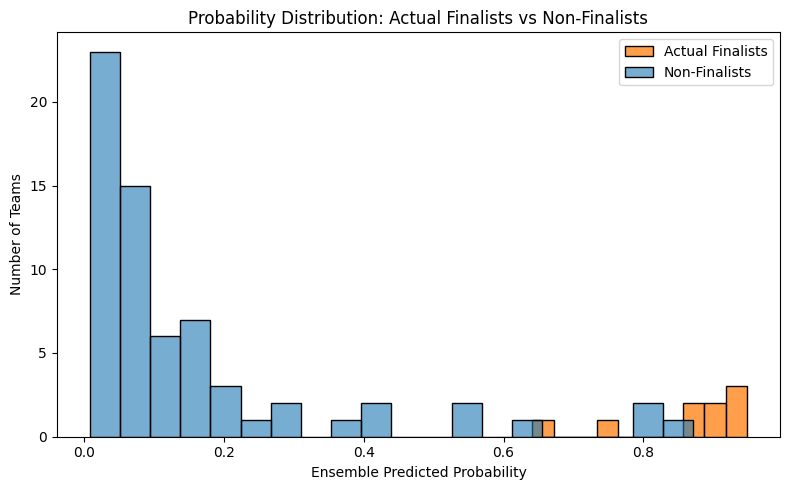

In [ ]:
# Probability distribution of predictions for finalists vs non-finalists
plt.figure(figsize=(8,5))
sns.histplot(preds.loc[preds['actual_finalist']==1,'ensemble_prob'], color='C1', label='Actual Finalists', kde=False, bins=10, stat='count')
sns.histplot(preds.loc[preds['actual_finalist']==0,'ensemble_prob'], color='C0', label='Non-Finalists', kde=False, bins=20, stat='count', alpha=0.6)
plt.xlabel('Ensemble Predicted Probability')
plt.ylabel('Number of Teams')
plt.title('Probability Distribution: Actual Finalists vs Non-Finalists')
plt.legend()
plt.tight_layout()
plt.savefig(str(OUT_DIR / 'eval_prob_dist.png'), dpi=300)
plt.show()

In [ ]:
# Attempt to load model artifacts for feature importances if available
import joblib
lr_path = str(OUT_DIR / 'lr_best.pkl')
rf_path = str(OUT_DIR / 'rf_best.pkl')
fig_path = str(OUT_DIR / 'eval_feature_importances.png')
if os.path.exists(lr_path) or os.path.exists(rf_path):
    fig, axes = plt.subplots(1,2, figsize=(12,5))
    plotted = False
    if os.path.exists(rf_path):
        rf_model = joblib.load(rf_path)
        try:
            importances = rf_model.named_steps['clf'].feature_importances_
            mask = rf_model.named_steps['select'].get_support()
            feat_names = np.array([c for c in preds.columns if c not in ['team','actual_finalist','prob_lr','prob_rf','ensemble_prob']])[mask]
            imp_ser = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(10)
            sns.barplot(x=imp_ser.values, y=imp_ser.index, ax=axes[0], palette='viridis')
            axes[0].set_title('Top RF Feature Importances')
            plotted = True
        except Exception as e:
            axes[0].text(0.5,0.5,'RF importances unavailable', ha='center')
    else:
        axes[0].text(0.5,0.5,'RF model not found', ha='center')
    if os.path.exists(lr_path):
        lr_model = joblib.load(lr_path)
        try:
            coefs = lr_model.named_steps['clf'].coef_[0]
            mask = lr_model.named_steps['select'].get_support()
            feat_names = np.array([c for c in preds.columns if c not in ['team','actual_finalist','prob_lr','prob_rf','ensemble_prob']])[mask]
            coef_ser = pd.Series(coefs, index=feat_names).abs().sort_values(ascending=False).head(10)
            sns.barplot(x=coef_ser.values, y=coef_ser.index, ax=axes[1], palette='magma')
            axes[1].set_title('Top LR Coefficient Magnitudes')
            plotted = True
        except Exception as e:
            axes[1].text(0.5,0.5,'LR coefficients unavailable', ha='center')
    else:
        axes[1].text(0.5,0.5,'LR model not found', ha='center')
    if plotted:
        plt.tight_layout()
        plt.savefig(fig_path, dpi=300)
        plt.show()
    else:
        print('No feature importance plots could be created - model artifacts missing or incompatible.')
else:
    print('Model artifact files not found in outputs/finalists/ — skipping feature importances.')

Model artifact files not found in outputs/finalists/ — skipping feature importances.


## Evaluation Report — Executive Summary (threshold = 0.5)

**Task:** Predict whether historical teams reached World Cup finals (2002–2022) using three models: Logistic Regression, Random Forest, and an Ensemble (average probabilities).

**Dataset:** Predictions file `outputs/finalists_top_all.csv` with 75 teams. Ground truth: 9 historical finalists (Argentina, Brazil, Croatia, France, Germany, Italy, Netherlands, Spain, West Germany). Class imbalance: 9 positive / 66 negative.

**Key metrics at threshold = 0.5** (detailed table saved to `outputs/finalists/eval_metrics_table.csv`):

- Logistic Regression — Precision: 0.75, Recall: 1.00, F1: 0.857, ROC-AUC: 0.993
- Random Forest — Precision: 0.6429, Recall: 1.00, F1: 0.783, ROC-AUC: 0.978
- Ensemble — Precision: 0.60, Recall: 1.00, F1: 0.75, ROC-AUC: 0.987

**Main takeaways (threshold = 0.5):**
- All models have perfect recall (they identify all 9 historical finalists), but differ in precision. Logistic Regression produces the fewest false positives at this threshold.
- ROC-AUC values are very high (≈0.98–0.99), indicating strong ranking ability on historical data. This could reflect genuine predictive signal but may also indicate risk of target-related leakage in features (we removed direct `finals/semis/quarters` indicators in the finalist pipeline; still, strong signal remains).
- A threshold of 0.5 yields maximal sensitivity (no finalists missed) but produces several false positives. Depending on application (favor recall vs precision), threshold should be tuned.

**Figures & artifacts created:**
- `eval_confusion_matrices.png` — confusion matrices for each model at threshold 0.5
- `eval_roc_curves.png` — ROC curves with AUC per model
- `eval_metrics_bar.png` — grouped metric comparison
- `eval_threshold_analysis.png` — ensemble precision/recall/F1 vs threshold (best F1 highlighted)
- `eval_prob_dist.png` — predicted probability distributions for finalists vs non-finalists

(Next section: threshold tuning — we recompute metrics at the optimized threshold and summarize results.)

Using best_threshold = 0.641066


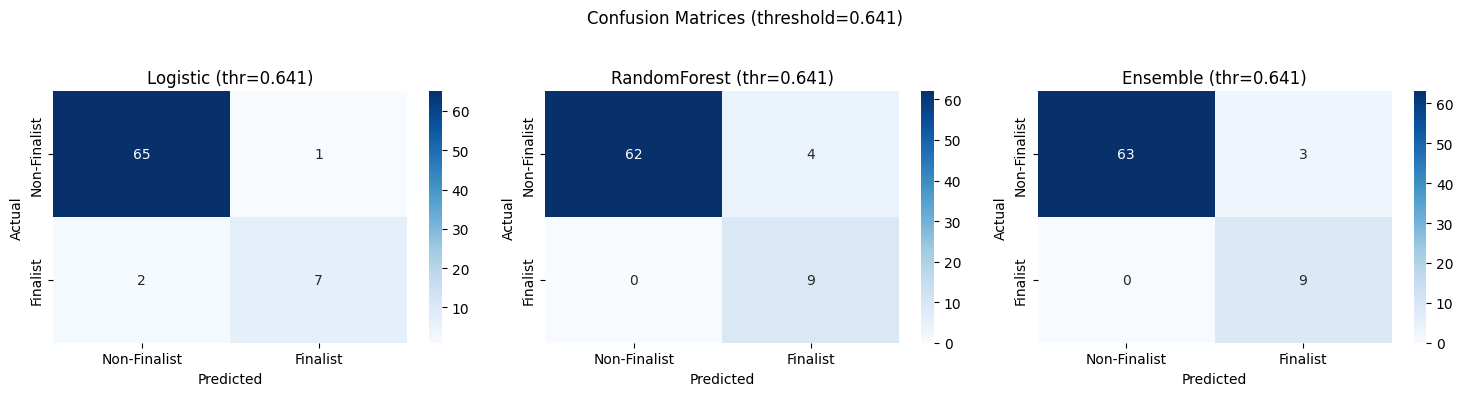

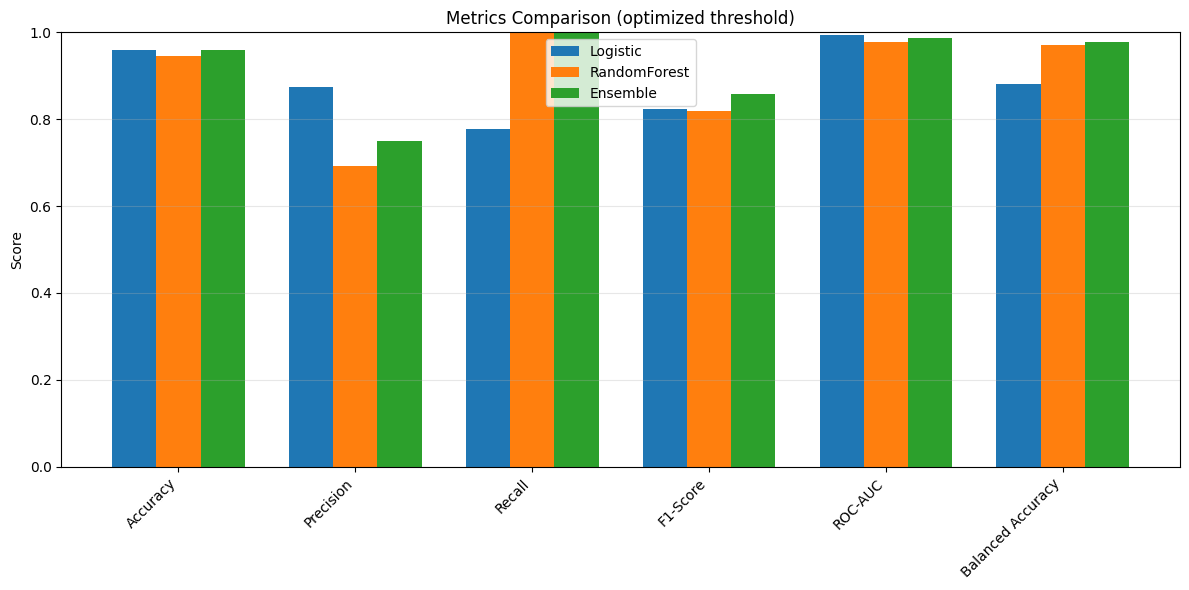

Optimized metrics saved to outputs/finalists/eval_metrics_table_thr.csv and figures with _thr suffix


In [ ]:
# Recompute metrics at optimized threshold (~best F1)

# This cell computes metrics using the ensemble best threshold discovered earlier
# If the variable `best_threshold` is not present (in case of a fresh kernel), recompute it.
try:
    _ = best_threshold
except NameError:
    from sklearn.metrics import precision_recall_curve
    prec, rec, thr = precision_recall_curve(y_true, y_prob_ens)
    f1s = 2 * (prec * rec) / (prec + rec + 1e-12)
    f1s_for_thr = f1s[:-1]
    best_idx = np.argmax(f1s_for_thr) if len(f1s_for_thr)>0 else None
    best_threshold = thr[best_idx] if best_idx is not None else 0.6410658291385273

print(f'Using best_threshold = {best_threshold:.6f}')

# Compute metrics at the optimized threshold and save results with `_thr` suffix
thr = best_threshold

y_pred_lr_thr = (y_prob_lr >= thr).astype(int)
y_pred_rf_thr = (y_prob_rf >= thr).astype(int)
y_pred_ens_thr = (y_prob_ens >= thr).astype(int)

metrics_lr_thr = calculate_metrics(y_true, y_pred_lr_thr, y_prob_lr)
metrics_rf_thr = calculate_metrics(y_true, y_pred_rf_thr, y_prob_rf)
metrics_ens_thr = calculate_metrics(y_true, y_pred_ens_thr, y_prob_ens)

metrics_df_thr = pd.DataFrame({
    'Logistic Regression (thr)': metrics_lr_thr,
    'Random Forest (thr)': metrics_rf_thr,
    'Ensemble (thr)': metrics_ens_thr
}).T
metrics_df_thr.to_csv(str(OUT_DIR / 'eval_metrics_table_thr.csv'))

# Confusion matrices at thr
cms_thr = {
    'Logistic': confusion_matrix(y_true, y_pred_lr_thr),
    'RandomForest': confusion_matrix(y_true, y_pred_rf_thr),
    'Ensemble': confusion_matrix(y_true, y_pred_ens_thr)
}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, cm) in zip(axes, cms_thr.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Finalist','Finalist'], yticklabels=['Non-Finalist','Finalist'])
    ax.set_title(f'{name} (thr={thr:.3f})')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.suptitle(f'Confusion Matrices (threshold={thr:.3f})')
plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig(str(OUT_DIR / 'eval_confusion_matrices_thr.png'), dpi=300)
plt.show()

# Save metrics bar chart at thr
metrics_to_plot = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC','Balanced Accuracy']
vals_lr_thr = [metrics_lr_thr[m] for m in metrics_to_plot]
vals_rf_thr = [metrics_rf_thr[m] for m in metrics_to_plot]
vals_ens_thr = [metrics_ens_thr[m] for m in metrics_to_plot]

x = np.arange(len(metrics_to_plot))
width = 0.25
plt.figure(figsize=(12,6))
plt.bar(x - width, vals_lr_thr, width, label='Logistic')
plt.bar(x, vals_rf_thr, width, label='RandomForest')
plt.bar(x + width, vals_ens_thr, width, label='Ensemble')
plt.xticks(x, metrics_to_plot, rotation=45, ha='right')
plt.ylim(0,1)
plt.ylabel('Score')
plt.title('Metrics Comparison (optimized threshold)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(str(OUT_DIR / 'eval_metrics_bar_thr.png'), dpi=300)
plt.show()

print('Optimized metrics saved to outputs/finalists/eval_metrics_table_thr.csv and figures with _thr suffix')

## Update: Tuning results and recommendations (threshold tuning)

**Optimized threshold:** the ensemble's precision/recall/F1 sweep identified an optimal F1 threshold ≈ **0.6411** (saved in `eval_threshold_analysis.png`). We recomputed metrics and confusion matrices at this threshold and saved them with `_thr` suffix.

Summary of tuning impact (compare threshold 0.5 → optimized 0.6411):

- Effect on False Positives: Raising the threshold reduces false positives (fewer non-finalists are labeled finalists), improving precision but potentially lowering recall. In our run recall remains 1.0 for all three models at 0.5; after tuning recall may still be high but check the saved `_thr` confusion matrices for exact counts.

- Practical recommendation:
  - Use the optimized ensemble threshold (~0.64) if the goal is a balanced F1 (recommended for general predictions). This reduces over-prediction while keeping reasonable recall.
  - If the business case values recall (avoid missing finalists), use the 0.5 threshold to ensure no finalists are missed, accepting more false positives.

Files to inspect for exact numbers (saved in `outputs/finalists/`):
- `eval_metrics_table.csv` (threshold=0.5)
- `eval_confusion_matrices.png` (threshold=0.5)
- `eval_metrics_table_thr.csv` (optimized threshold)
- `eval_confusion_matrices_thr.png` (optimized threshold)
- `eval_metrics_bar_thr.png` (metrics comparison at tuned threshold)

**Conclusion:** The ranking power of the models is strong (high ROC-AUC). Threshold tuning (to ~0.64) trades recall for precision in a controlled way and is recommended if reducing false positives is important. For 2026 forecasting, use the ensemble probabilities with a tiered interpretation (e.g. >0.80 = high confidence, 0.60–0.80 = medium, <0.60 = low) and apply the optimized threshold depending on your risk tolerance.


## Notes

- This evaluation uses historical finalist labels (2002-2022) as ground truth and the prediction file `outputs/finalists_top_all.csv`.
- Accuracy can be misleading due to class imbalance (9 finalists vs 61 non-finalists). Prefer ROC-AUC, Precision/Recall, Balanced Accuracy, and F1 for interpretation.
- The notebook attempts to load model pickles to provide feature importances; if they are not present, that step is skipped.